# Hospital Emergency Department Operations Analysis

## Business Understanding

### Business Problem

Hospitals often face operational challenges in Emergency Departments, including:

- Long patient waiting times
- Low patient satisfaction
- Inefficient resource allocation

### Business Objectives

This project aims to use data analysis to:

- Reduce patient waiting time in the Emergency Department (ED)
- Improve patient satisfaction
- Optimize hospital operational efficiency

## Import Libraries

In [1]:
!pip install ydata-profiling -q


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
%matplotlib inline

### 1. Load and Explore the Dataset

In [3]:
data = pd.read_csv('hospital_operation_clean.csv')

In [4]:
data.head()

,patient_admission_date,patient_admission_time,patient_id,merged,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
0,2024-09-09,20:33:00,404-43-9499,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
1,2024-09-09,19:25:00,552-51-5855,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36
2,2024-09-09,13:14:00,536-68-0475,T. Shillaker,Female,25,African American,General Practice,Admission,6.0,14
3,2023-09-09,13:19:00,215-29-2936,B. Emberson,Female,44,African American,NaN,Admission,NaN,53
4,2023-09-09,23:21:00,824-34-1887,A. Coushe,Male,42,African American,NaN,Admission,NaN,54


In [5]:
data.tail()

,patient_admission_date,patient_admission_time,patient_id,merged,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
9211,2023-10-01,04:06:00,636-65-9131,C. Melladew,Female,74,White,NaN,Not Admission,NaN,40
9212,2023-10-01,08:27:00,802-43-8558,O. Pusey,Female,57,White,NaN,Not Admission,NaN,11
9213,2024-01-01,12:55:00,533-87-1299,E. Brownlee,Female,28,White,NaN,Not Admission,NaN,57
9214,2024-01-01,23:01:00,353-25-3957,S. Levermore,Male,19,White,Cardiology,Not Admission,NaN,34
9215,2024-01-01,04:59:00,641-52-3173,L. Harford,Female,37,White,NaN,Not Admission,5.0,10


In [6]:
data.shape

(9216, 11)

#### Initial Observations

- The dataset contains **9,216 records** and **11 columns**.
- No duplicate records were identified.

The dataset provides information on:

- Patient waiting time in the Emergency Department (ED)
- Patient volume handled by each department
- Patient admission decisions

### 2. Data Cleaning

<b> Remove Non-Informative Data

In [7]:
drop_cols = ['patient_id', 'merged']
data.drop(drop_cols, axis = 1, inplace = True)

data.head()

,patient_admission_date,patient_admission_time,patient_gender,patient_age,patient_race,department_referral,patient_admission_flag,patient_satisfaction_score,patient_waittime
0,2024-09-09,20:33:00,Male,79,African American,General Practice,Admission,NaN,38
1,2024-09-09,19:25:00,Female,24,African American,NaN,Admission,NaN,36
2,2024-09-09,13:14:00,Female,25,African American,General Practice,Admission,6.0,14
3,2023-09-09,13:19:00,Female,44,African American,NaN,Admission,NaN,53
4,2023-09-09,23:21:00,Male,42,African American,NaN,Admission,NaN,54


<b> Check Missing Values

In [8]:
missing = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(data)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
patient_satisfaction_score,6699,72.688802
department_referral,5400,58.593750
patient_admission_date,0,0.000000
patient_admission_time,0,0.000000
patient_gender,0,0.000000
patient_race,0,0.000000
patient_age,0,0.000000
patient_admission_flag,0,0.000000
patient_waittime,0,0.000000


In [9]:
# Notes:
# department_referral (58.6%)
#     → Replace with 'None', as some patients did not require referral to a specialist department.
#
# patient_satisfaction_score (72.7%)
#     → Keep NaN (do not impute); analyze only records with valid values.
#     → Create a missing flag to check for bias caused by missing satisfaction data.

In [10]:
# 'department_referral' 

data['department_referral'] = data['department_referral'].fillna('None')

In [11]:
# 'patient_satisfaction_score'

# Create a missing flag for patient_satisfaction_score
data['satisfaction_missing_flag'] = data['patient_satisfaction_score'].isna().astype(int)

# Check missing value count
data['satisfaction_missing_flag'].value_counts()

satisfaction_missing_flag
1    6699
0    2517
Name: count, dtype: int64

<b>  Check missing data bias for `patient_satisfaction_score`

In [12]:
data['satisfaction_missing_flag'].value_counts(normalize=True) * 100

satisfaction_missing_flag
1    72.688802
0    27.311198
Name: proportion, dtype: float64

In [13]:
# Compare waiting time between missing and non-missing groups
data.groupby('satisfaction_missing_flag')['patient_waittime'].describe()

,count,mean,std,min,25%,50%,75%,max
satisfaction_missing_flag,,,,,,,,
0,2517.0,35.351212,14.852207,10.0,23.0,36.0,48.0,60.0
1,6699.0,35.225556,14.692134,10.0,23.0,35.0,48.0,60.0


In [14]:
# Compare department between missing and non-missing groups
pd.crosstab(
    data['department_referral'],
    data['satisfaction_missing_flag'],
    normalize='columns'
) * 100

satisfaction_missing_flag,0,1
department_referral,,
Cardiology,2.820818,2.642185
Gastroenterology,2.145411,1.851023
General Practice,19.984108,19.958203
Neurology,2.105681,2.089864
None,57.210965,59.113300
Orthopedics,11.521653,10.523959
Physiotherapy,3.297576,2.881027
Renal,0.913786,0.940439


In [15]:
# Compare by admission hour

# Extract the admission hour from patient_admission_time
data['patient_hour'] = pd.to_datetime(
    data['patient_admission_time'],
    format='%H:%M:%S'
).dt.hour

data[['patient_admission_time', 'patient_hour']].head()

,patient_admission_time,patient_hour
0,20:33:00,20
1,19:25:00,19
2,13:14:00,13
3,13:19:00,13
4,23:21:00,23


In [16]:
pd.crosstab(
    data['patient_hour'],
    data['satisfaction_missing_flag'],
    normalize='columns'
) * 100

satisfaction_missing_flag,0,1
patient_hour,,
0,4.092173,4.523063
1,3.734605,4.149873
2,4.330552,3.985670
3,4.449742,4.075235
4,4.251093,4.134946
5,3.814064,4.433498
6,3.814064,4.164801
7,3.933254,4.717122
8,4.131903,4.209584


In [17]:
# Notes:
# Missing satisfaction scores do not show clear evidence of bias → keep NaN values.

<b> Check Variable Values

In [18]:
cols = ['patient_gender', 'patient_race', 'department_referral', 'patient_admission_flag']

for col in cols:
    print(f"\nColumn: {col}")
    print(data[col].unique())


Column: patient_gender
['Male' 'Female' 'Femaleemale']

Column: patient_race
['African American' 'Asian' 'Declined to Identify'
 'Native American/Alaska Native' 'Pacific Islander' 'Two or More Races'
 'White']

Column: department_referral
['General Practice' 'None' 'Orthopedics' 'Cardiology' 'Gastroenterology'
 'Physiotherapy' 'Neurology' 'Renal']

Column: patient_admission_flag
['Admission' 'Not Admission']


In [19]:
# Notes:
# Correct a typo in patient_gender: 'Femaleemale' → 'Female'

In [20]:
data['patient_gender'].value_counts()

patient_gender
Male           4729
Female         4470
Femaleemale      17
Name: count, dtype: int64

In [21]:
data['patient_gender'] = data['patient_gender'].replace('Femaleemale','Female')
data['patient_gender'].value_counts()

patient_gender
Male      4729
Female    4487
Name: count, dtype: int64

<b> Check Data Types

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_admission_date      9216 non-null   object 
 1   patient_admission_time      9216 non-null   object 
 2   patient_gender              9216 non-null   object 
 3   patient_age                 9216 non-null   int64  
 4   patient_race                9216 non-null   object 
 5   department_referral         9216 non-null   object 
 6   patient_admission_flag      9216 non-null   object 
 7   patient_satisfaction_score  2517 non-null   float64
 8   patient_waittime            9216 non-null   int64  
 9   satisfaction_missing_flag   9216 non-null   int64  
 10  patient_hour                9216 non-null   int32  
dtypes: float64(1), int32(1), int64(3), object(6)
memory usage: 756.1+ KB


In [23]:
# Notes:
# Some data types are not appropriate. Convert them to datetime and category.

In [24]:
# Datetime

# Admission date
data['patient_admission_date'] = pd.to_datetime(data['patient_admission_date'], format='%Y-%m-%d')

# Admission time
data['patient_admission_time'] = pd.to_datetime(data['patient_admission_time'], format='%H:%M:%S')

In [25]:
# Category

for col in cols:
    data[col] = data[col].astype('category')

In [26]:
# Re-check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   patient_admission_date      9216 non-null   datetime64[ns]
 1   patient_admission_time      9216 non-null   datetime64[ns]
 2   patient_gender              9216 non-null   category      
 3   patient_age                 9216 non-null   int64         
 4   patient_race                9216 non-null   category      
 5   department_referral         9216 non-null   category      
 6   patient_admission_flag      9216 non-null   category      
 7   patient_satisfaction_score  2517 non-null   float64       
 8   patient_waittime            9216 non-null   int64         
 9   satisfaction_missing_flag   9216 non-null   int64         
 10  patient_hour                9216 non-null   int32         
dtypes: category(4), datetime64[ns](2), float64(1), int32(1),

### 3. Descriptive Statistics Overview

In [27]:
data.describe(include = 'number')

,patient_age,patient_satisfaction_score,patient_waittime,satisfaction_missing_flag,patient_hour
count,9216.000000,2517.000000,9216.000000,9216.000000,9216.000000
mean,39.855143,4.992054,35.259874,0.726888,11.486328
std,22.755125,3.138043,14.735323,0.445582,6.955110
min,1.000000,0.000000,10.000000,0.000000,0.000000
25%,20.000000,2.000000,23.000000,0.000000,5.000000
50%,39.000000,5.000000,35.000000,1.000000,11.000000
75%,60.000000,8.000000,48.000000,1.000000,18.000000
max,79.000000,10.000000,60.000000,1.000000,23.000000


##### <b> Findings <b/>
- The average waiting time is approximately 35 minutes, indicating stable overall operations.
- The average patient satisfaction score is approximately 5 out of 10, suggesting considerable room for improvement in the patient experience.
- The dataset covers a wide range of age groups, indicating that the Emergency Department serves a diverse patient population.

In [28]:
data.describe(include='category')

,patient_gender,patient_race,department_referral,patient_admission_flag
count,9216,9216,9216,9216
unique,2,7,8,2
top,Male,White,None,Admission
freq,4729,2571,5400,4612


##### <b> Findings <b/>
- The gender distribution is relatively balanced.
- Most patients did not require referral to a specialist department.
- The proportions of admitted and non-admitted patients are relatively balanced, indicating the need for further analysis by waiting time and department.

### 4. Distribution Analysis and Outlier Detection

<B> Patient_waittime

In [29]:
# IQR method
Q1 = data['patient_waittime'].quantile(0.25)
Q3 = data['patient_waittime'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['patient_waittime'] < lower_bound) |
    (data['patient_waittime'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Outlier percentage:", round(len(outliers) / len(data) * 100, 2), "%")

Number of outliers: 0
Outlier percentage: 0.0 %


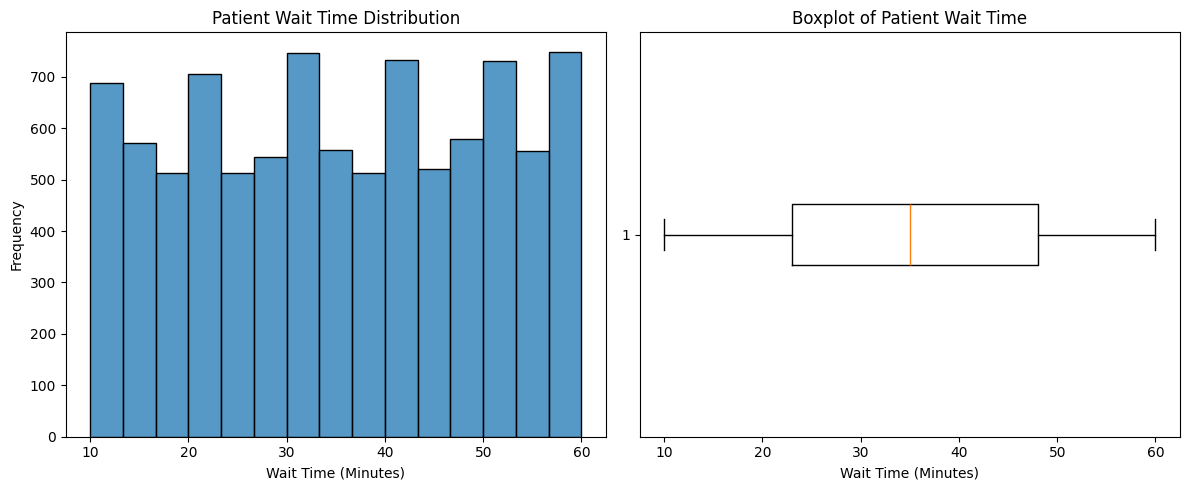

In [30]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)

sns.histplot( data=data, x='patient_waittime', bins=15)
plt.title('Patient Wait Time Distribution')
plt.xlabel('Wait Time (Minutes)')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)

plt.boxplot(data['patient_waittime'], vert=False)
plt.title('Boxplot of Patient Wait Time')
plt.xlabel('Wait Time (Minutes)')

plt.tight_layout()
plt.show()

##### <b> Findings <b/>
- The data is relatively evenly distributed, with no significant distribution skewness.
- No outliers were identified.

<b> Patient_satisfaction_score

In [31]:
# IQR method
Q1 = data['patient_satisfaction_score'].quantile(0.25)
Q3 = data['patient_satisfaction_score'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['patient_satisfaction_score'] < lower_bound) |
    (data['patient_satisfaction_score'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Outlier percentage:", round(len(outliers) / len(data) * 100, 2), "%")

Number of outliers: 0
Outlier percentage: 0.0 %


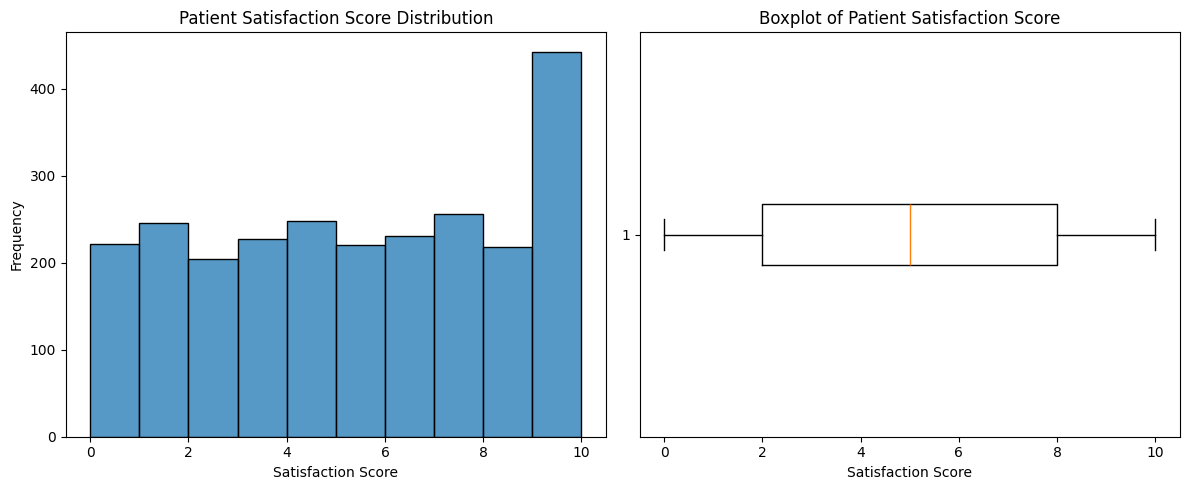

In [32]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)

sns.histplot( data=data, x='patient_satisfaction_score', bins=10)
plt.title('Patient Satisfaction Score Distribution')
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)

plt.boxplot(data['patient_satisfaction_score'].dropna(), vert=False)
plt.title('Boxplot of Patient Satisfaction Score')
plt.xlabel('Satisfaction Score')

plt.tight_layout()
plt.show()

##### <b> Findings <b/>
- A considerable proportion of patients reported very high satisfaction scores (score = 10).
- No outliers were identified.
- However, a group of patients still reported low satisfaction scores, warranting further analysis.

### 5. Emergency Department Operational Overview

<b>Patient Volume Analysis Over Time</b> 

In [33]:
# 1. Patient Volume by Hour
volume_by_hour = data.groupby('patient_hour').size().reset_index(name='patient_count')

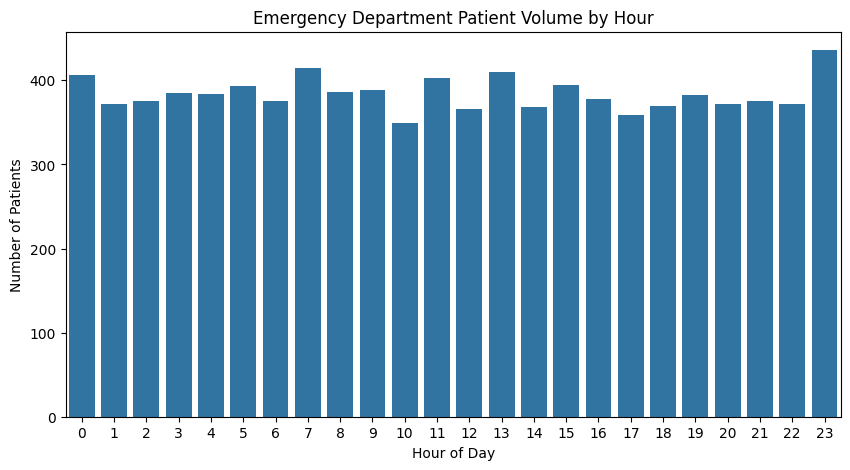

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=volume_by_hour, 
    x='patient_hour', 
    y='patient_count'
)

plt.title('Emergency Department Patient Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Patients')
plt.show()

##### <b> Findings <b/>  
- The Emergency Department operates continuously throughout the day, with patient volume relatively evenly distributed across hours.  
- No clear signs of overcrowding were observed based solely on patient volume over time.  

In [35]:
# 2. Patient Volume by Month
volume_by_month = (data.groupby(data['patient_admission_date'].dt.month).size().reset_index(name='patient_count'))
volume_by_month.columns = ['month', 'patient_count']

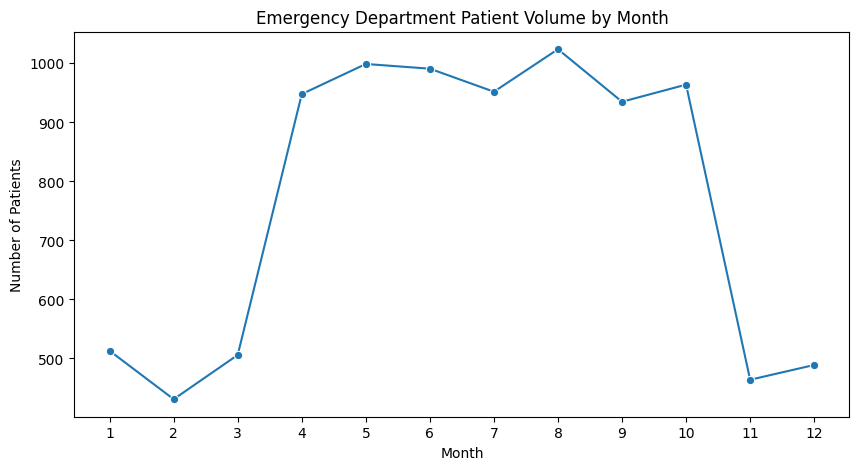

In [36]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=volume_by_month,
    x='month',
    y='patient_count',
    marker='o'
)

plt.title('Emergency Department Patient Volume by Month')
plt.xlabel('Month')
plt.ylabel('Number of Patients')

plt.xticks(volume_by_month['month'])

plt.show()

##### <b> Findings <b/>
- Patient volume in the Emergency Department increased significantly from April to October, nearly doubling compared to the beginning and end of the year.  
- August recorded the highest patient volume, with more than 1,000 patient visits.  
- The results indicate a clear seasonal workload pattern.  

<b>Admission Analysis</b>  

In [37]:
# 1. Patient Admissions by Hour
admission_by_hour = (
    data.groupby(['patient_hour', 'patient_admission_flag'])
    .size()
    .reset_index(name='patient_count')
)

C:\Users\VINH PHU\AppData\Local\Temp\ipykernel_20156\435779788.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['patient_hour', 'patient_admission_flag'])


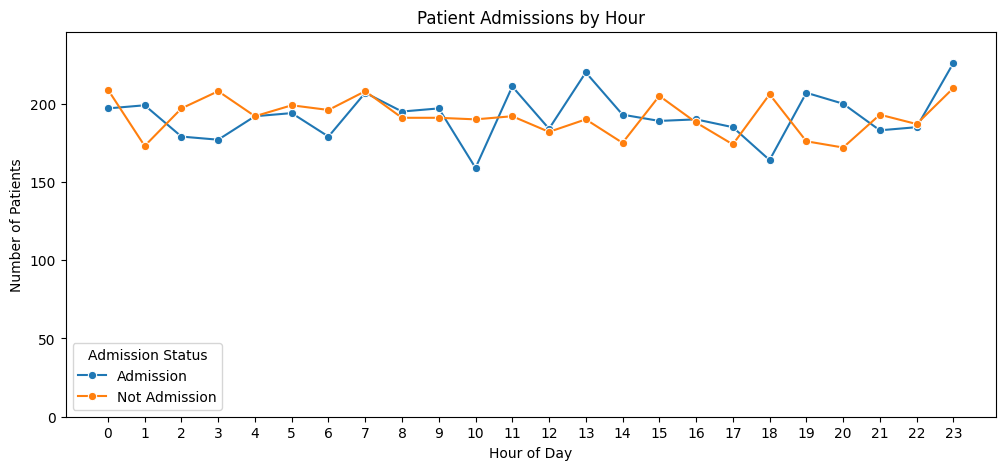

In [38]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=admission_by_hour,
    x='patient_hour',
    y='patient_count',
    hue='patient_admission_flag',
    marker='o'
)

plt.title('Patient Admissions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Patients')

plt.xticks(range(24))
plt.legend(title='Admission Status')
plt.ylim(0, admission_by_hour['patient_count'].max() + 20)

plt.show()

##### <b> Findings <b/>
- The number of admitted and non-admitted patients remained relatively stable throughout the day.
- No distinct peak hours were observed for patient admissions.
- A slight increase in admissions was observed during certain hours, but the differences were not substantial.

In [39]:
# 2. Patient Admissions by Department
admission_by_department = (
    data.groupby(['department_referral', 'patient_admission_flag'])
    .size()
    .reset_index(name='patient_count')
)

admission_by_department = admission_by_department[
    admission_by_department['department_referral'] != 'None'
].copy()

admission_by_department['department_referral'] = (
    admission_by_department['department_referral']
    .cat.remove_unused_categories()
)

C:\Users\VINH PHU\AppData\Local\Temp\ipykernel_20156\919519231.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['department_referral', 'patient_admission_flag'])


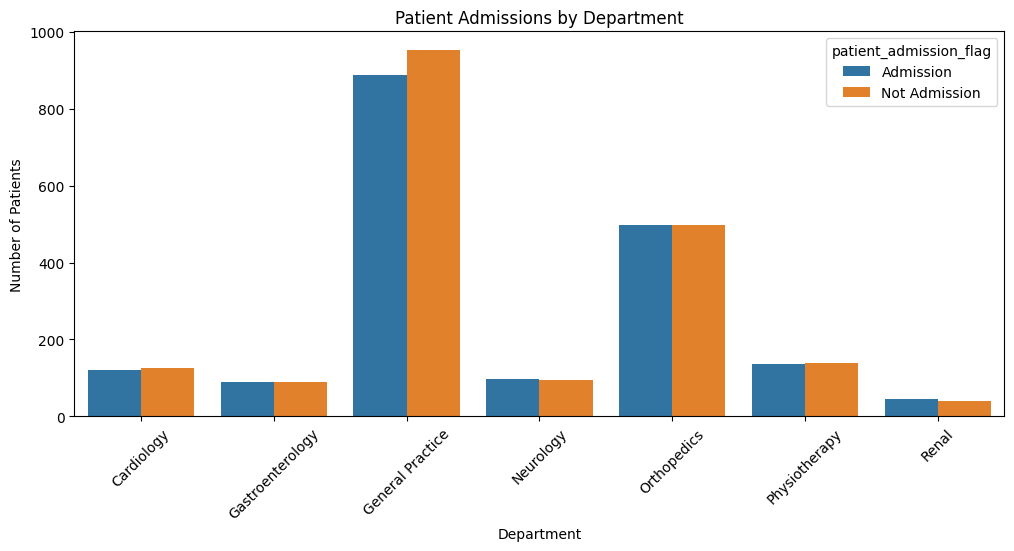

In [40]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=admission_by_department,
    x='department_referral',
    y='patient_count',
    hue='patient_admission_flag'
)

plt.title('Patient Admissions by Department')
plt.xlabel('Department')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45)

plt.show()

##### <b> Findings <b/>
- General Practice and Orthopedics handled the highest patient volume.
- The proportions of admitted and non-admitted patients were relatively balanced across departments.
- No department showed a clearly higher admission rate than the others.

#### <b>Summary  <b/>
- The Emergency Department operated with a relatively consistent workload throughout the day, indicating stable patient demand rather than concentration during a few peak hours.  
- Although patient volume was slightly higher during certain hours, the differences were not large enough to indicate distinct peak periods.  
- Patient volume increased substantially from April to October, suggesting a seasonal workload pattern. Staffing and resource allocation should be adjusted accordingly to reduce the risk of operational strain.  
- Admission rates remained relatively consistent throughout the day, indicating that admission demand was not concentrated during specific hours.  
- From an overall operational perspective, no strong signs of system-wide overcrowding were observed based solely on patient volume.  

### 6. Department Workload Analysis

In [41]:
# Exclude 'None' values
department_data = data[
    data['department_referral'] != 'None'
].copy()

department_data['department_referral'] = (
    department_data['department_referral']
    .cat.remove_unused_categories()
)

<b>Waiting Time Distribution by Department</b>

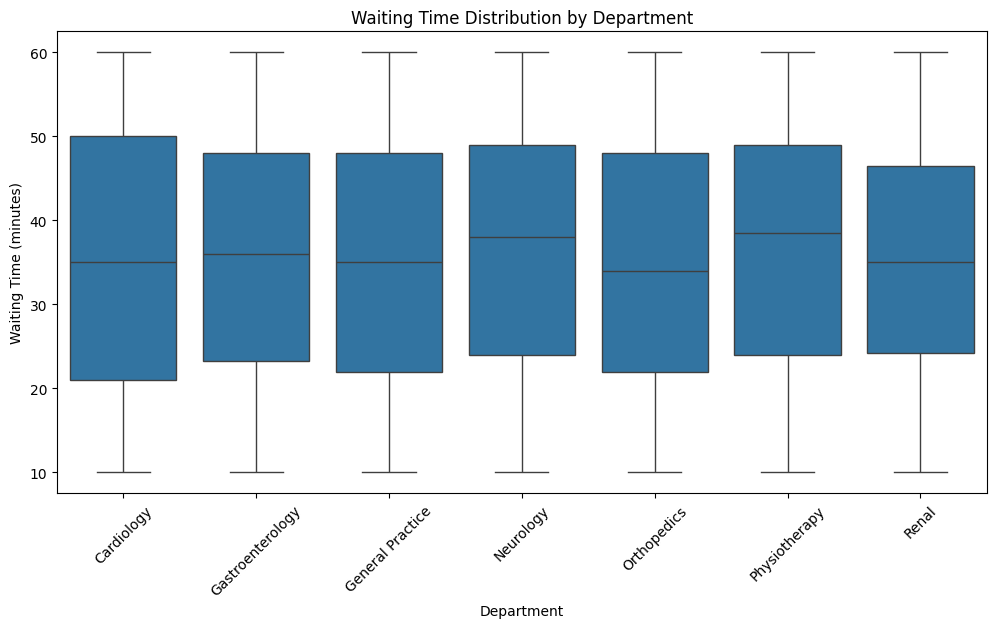

In [42]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=department_data,
    x='department_referral',
    y='patient_waittime'
)

plt.title('Waiting Time Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Waiting Time (minutes)')

plt.xticks(rotation=45)

plt.show()

<b> Findings <b/>
- Waiting time variability is relatively consistent across departments, with similar median waiting times.
- No department shows clear evidence of significantly longer waiting times or operational congestion.

<b>Patient Volume vs. Waiting Time by Department</b>

In [43]:
dept_analysis = (
    department_data
    .groupby('department_referral')
    .agg(
        patient_count=('department_referral', 'size'),
        avg_waiting_time=('patient_waittime', 'mean'),
        median_waiting_time=('patient_waittime', 'median'),
        min_waiting_time=('patient_waittime', 'min'),
        max_waiting_time=('patient_waittime', 'max')
    )
    .reset_index()
)

dept_analysis = dept_analysis.sort_values(
    by='patient_count',
    ascending=False
)

dept_analysis

C:\Users\VINH PHU\AppData\Local\Temp\ipykernel_20156\5757810.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('department_referral')


,department_referral,patient_count,avg_waiting_time,median_waiting_time,min_waiting_time,max_waiting_time
2,General Practice,1840,34.912500,35.0,10,60
4,Orthopedics,995,34.982915,34.0,10,60
5,Physiotherapy,276,36.565217,38.5,10,60
0,Cardiology,248,35.354839,35.0,10,60
3,Neurology,193,36.803109,38.0,10,60
1,Gastroenterology,178,35.831461,36.0,10,60
6,Renal,86,34.697674,35.0,10,60


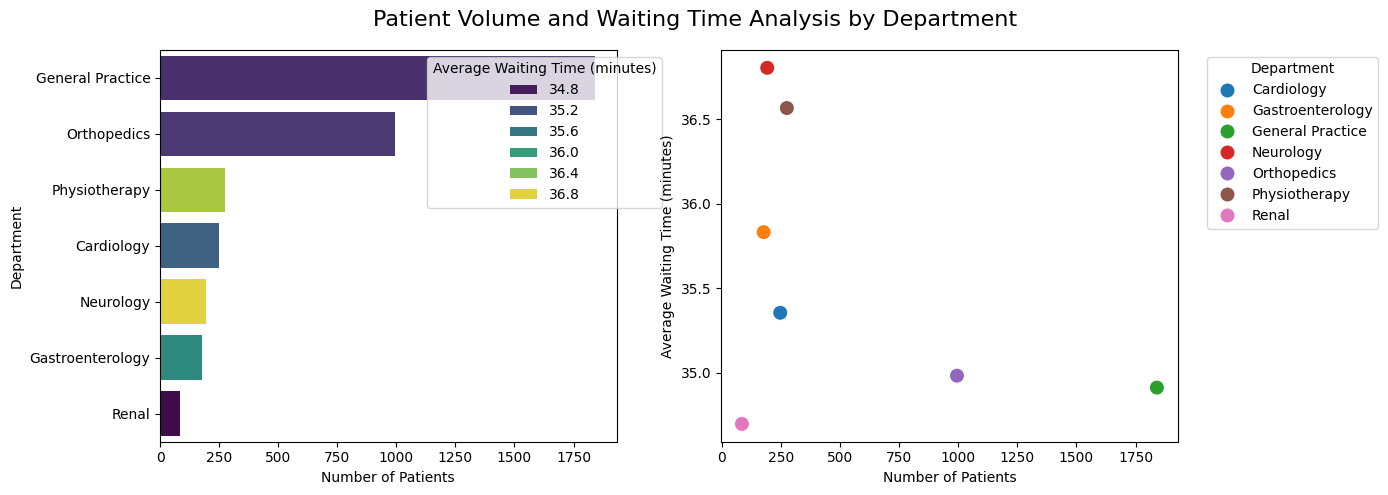

In [44]:
plt.figure(figsize=(14, 5))
plt.suptitle(
    'Patient Volume and Waiting Time Analysis by Department',
    fontsize=16
)

# Chart 1
plt.subplot(1, 2, 1)

sns.barplot(
    data=dept_analysis,
    x='patient_count',
    y='department_referral',
    hue='avg_waiting_time',
    palette='viridis',
    order=dept_analysis['department_referral']
)

plt.xlabel('Number of Patients')
plt.ylabel('Department')

plt.legend(
    title='Average Waiting Time (minutes)',
    bbox_to_anchor=(0.57, 1),
    loc='upper left'
)

# Chart 2
plt.subplot(1, 2, 2)

sns.scatterplot(
    data=dept_analysis,
    x='patient_count',
    y='avg_waiting_time',
    hue='department_referral',
    s=120
)

plt.xlabel('Number of Patients')
plt.ylabel('Average Waiting Time (minutes)')

plt.legend(
    title='Department',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()

<b> Findings <b/>
- General Practice and Orthopedics handle the highest patient volumes.
- General Practice maintains a relatively stable waiting time despite its high patient volume, while Neurology shows a comparatively longer average waiting time.
- No clear relationship is observed between patient volume and average waiting time across departments.

#### <b>Summary  <b/>
- General Practice and Orthopedics handled the highest patient volumes while maintaining relatively stable waiting times, suggesting no clear operational bottlenecks caused by workload.
- Neurology recorded one of the highest average waiting times despite a relatively low patient volume, indicating that waiting time may be influenced more by the complexity of care than by patient demand.
- Waiting time distributions were generally consistent across departments, with no department showing unusual variation or clear signs of severe operational congestion.
- Overall, the findings suggest that current operational bottlenecks are more likely associated with department-specific processes than with overall patient volume.

### 7. Department Workload and Waiting Time

In [45]:
# Extract month from the datetime column
data['patient_month'] = data['patient_admission_date'].dt.month

<b>Workload and Waiting Time by Month</b>

In [46]:
waiting_by_month = (
    data
    .groupby('patient_month')
    .agg(
        patient_count=('patient_waittime', 'size'),
        avg_waiting_time=('patient_waittime', 'mean'),
        median_waiting_time=('patient_waittime', 'median')
    )
    .reset_index()
)

waiting_by_month

,patient_month,patient_count,avg_waiting_time,median_waiting_time
0,1,513,36.323587,37.0
1,2,431,36.670534,37.0
2,3,506,35.879447,36.0
3,4,948,34.972574,35.0
4,5,999,35.146146,35.0
5,6,991,35.544904,37.0
6,7,952,34.965336,35.0
7,8,1024,35.730469,36.0
8,9,935,34.663102,34.0
9,10,964,34.502075,34.0


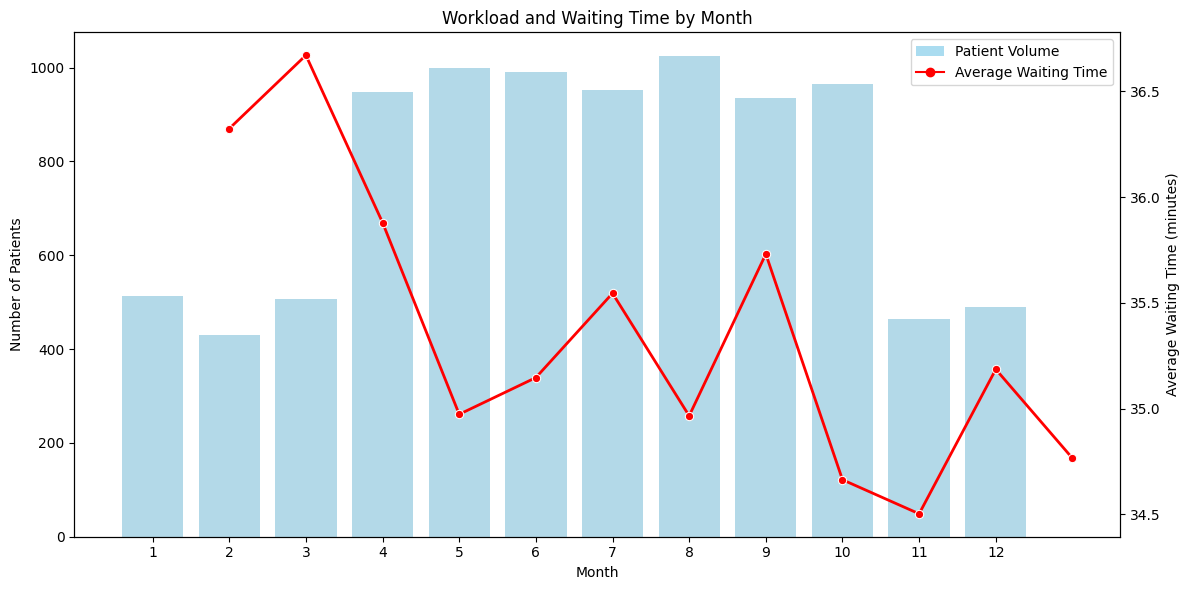

In [47]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barplot
sns.barplot(
    data=waiting_by_month,
    x='patient_month',
    y='patient_count',
    color='skyblue',
    alpha=0.7,
    ax=ax1
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Patients')

# Lineplot
ax2 = ax1.twinx()

sns.lineplot(
    data=waiting_by_month,
    x='patient_month',
    y='avg_waiting_time',
    marker='o',
    color='red',
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Average Waiting Time (minutes)')

# Custom legend
legend_elements = [
    Patch(facecolor='skyblue', alpha=0.7, label='Patient Volume'),
    Line2D([0], [0], color='red', marker='o', label='Average Waiting Time')
]

ax1.legend(handles=legend_elements, loc='upper right')

plt.title('Workload and Waiting Time by Month')

plt.tight_layout()
plt.show()

<b> Findings <b/>  
- Average waiting time does not increase proportionally with the seasonal rise in patient volume. Despite higher patient demand from April to October, the Emergency Department maintains relatively stable operational performance.
- These findings suggest that seasonal workload is not the primary driver of longer waiting times and does not result in system-wide operational congestion.
- The dataset does not include several key operational factors, such as patient acuity, staffing levels, triage priority, or queue length. Therefore, the root causes of waiting time cannot be determined with confidence based on the available data.

### <b> 8. Long Waiting Time Analysis

<b>Define the Long Waiting Time Threshold

In [48]:
# Top 10% waiting time threshold

long_wait_threshold = data["patient_waittime"].quantile(0.90)

print(f"Long waiting time threshold: {long_wait_threshold:.2f} minutes")

# Create a long waiting time flag

data["long_wait"] = data["patient_waittime"] >= long_wait_threshold

# Check the distribution

data["long_wait"].value_counts(normalize=True) * 100

Long waiting time threshold: 56.00 minutes


long_wait
False    89.854601
True     10.145399
Name: proportion, dtype: float64

<b>Long Waiting Patients by Department

In [49]:
# Exclude 'None' values
department_data = data[
    data["department_referral"] != "None"
].copy()

department_data["department_referral"] = (
    department_data["department_referral"]
    .cat.remove_unused_categories()
)

In [50]:
dept_long_wait_summary = (
    department_data
    .groupby("department_referral", observed=True)
    .agg(
        patient_count=("department_referral", "size"),
        long_wait_cases=("long_wait", "sum"),
        long_wait_rate=("long_wait", "mean")
    )
    .reset_index()
)

dept_long_wait_summary["long_wait_rate"] = (
    dept_long_wait_summary["long_wait_rate"] * 100
)

dept_long_wait_summary = (
    dept_long_wait_summary
    .sort_values("long_wait_cases", ascending=False)
)

dept_long_wait_summary

,department_referral,patient_count,long_wait_cases,long_wait_rate
2,General Practice,1840,186,10.108696
4,Orthopedics,995,104,10.452261
5,Physiotherapy,276,35,12.681159
0,Cardiology,248,28,11.290323
3,Neurology,193,24,12.435233
1,Gastroenterology,178,18,10.112360
6,Renal,86,6,6.976744


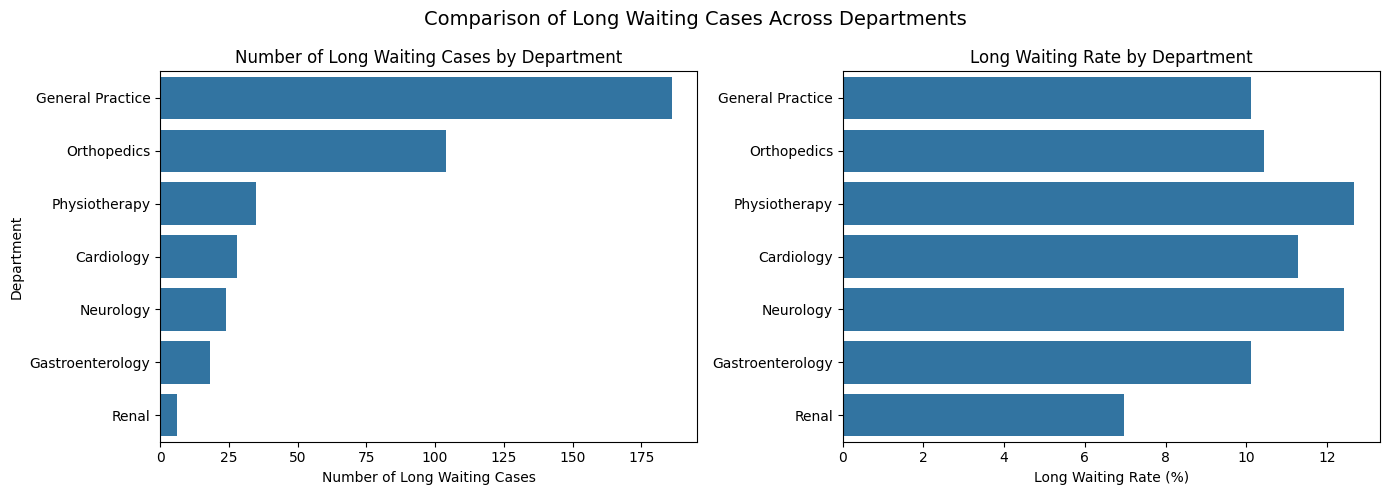

In [51]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5)
)

# Số lượng ca chờ lâu theo khoa
sns.barplot(
    data=dept_long_wait_summary,
    x="long_wait_cases",
    y="department_referral",
    order=dept_long_wait_summary["department_referral"],
    ax=axes[0]
)

axes[0].set_title("Number of Long Waiting Cases by Department")
axes[0].set_xlabel("Number of Long Waiting Cases")
axes[0].set_ylabel("Department")

# Tỷ lệ bệnh nhân chờ lâu theo khoa
sns.barplot(
    data=dept_long_wait_summary,
    x="long_wait_rate",
    y="department_referral",
    order=dept_long_wait_summary["department_referral"],
    ax=axes[1]
)

axes[1].set_title("Long Waiting Rate by Department")
axes[1].set_xlabel("Long Waiting Rate (%)")
axes[1].set_ylabel("")

plt.suptitle(
    "Comparison of Long Waiting Cases Across Departments",
    fontsize=14
)

plt.tight_layout()
plt.show()

<b> Findings <b/>
- The proportion of long waiting patients is relatively consistent across departments, ranging from approximately 7% to 13%, with no department showing a noticeably higher concentration of long waiting cases.
- Departments with a higher number of long waiting cases generally also handle larger patient volumes, suggesting that the absolute number of long waiting cases is primarily driven by patient volume rather than an unusually high long waiting rate.

## Business Recommendations

### 1. Adjust Staffing Based on Seasonal Demand

#### Supporting Findings

- Patient volume increases substantially from April to October.
- August records the highest patient volume.

#### Recommendation

- Adjust staffing plans based on seasonal demand rather than maintaining a fixed staffing level throughout the year.
- Allocate additional resources during peak months to maintain service quality and operational efficiency.

---

### 2. Closely Monitor High-Volume Departments

#### Supporting Findings

- General Practice and Orthopedics handle the highest patient volumes.

#### Recommendation

- Regularly monitor patient volume and waiting time in these departments.
- Prioritize resource allocation to departments with consistently high patient demand.

---

### 3. Review Departments with Relatively Longer Waiting Times

#### Supporting Findings

- Neurology and Physiotherapy have relatively higher average waiting times than other departments.

#### Recommendation

- Review patient flow and operational processes in these departments.
- Identify department-specific factors that may contribute to longer waiting times.

---

### 4. Collect Additional Operational Data

#### Supporting Findings

- The current dataset is insufficient to identify the root causes of longer waiting times.

#### Recommendation

Collect additional operational data, including:

- Patient acuity level
- Staffing levels by shift
- Queue length
- Consultation or treatment duration

---

## Conclusion

The current analysis does not indicate clear signs of system-wide operational congestion. However, the hospital could further improve operational efficiency by:

- Adjusting staffing based on seasonal demand.
- Closely monitoring high-volume departments.
- Reviewing departments with relatively longer waiting times.
- Collecting additional operational data to better understand the factors influencing patient waiting time.